<a href="https://colab.research.google.com/github/kallydimitrova/HEPexercises/blob/main/Exercise2_Fermi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 12, "font.family": "serif", "axes.linewidth": 1.0,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "legend.frameon": False, "savefig.bbox": "tight",
})

In [ ]:
import glob
import numpy as np
from astropy.io import fits
from astropy.table import Table, vstack

def load_fermi_events(path):
    with fits.open(path) as hdul:
        events = Table(hdul["EVENTS"].data)
        gti = Table(hdul["GTI"].data)
    return events, gti

def load_weekly_events(paths):
    tables = []
    for path in sorted(paths):
        events, _ = load_fermi_events(path)
        tables.append(events)
        print(f"{path}: {len(events)} events")
    return vstack(tables)

week_paths = sorted(glob.glob("data/weekly/lat_photon_weekly_w*.fits"))
print(f"Found {len(week_paths)} weekly files")
all_sky_events = load_weekly_events(week_paths)
print(f"Total events after concatenation: {len(all_sky_events)}")

Found 5 weekly files
data/weekly/lat_photon_weekly_w701_p305_v001.fits: 2258152 events
data/weekly/lat_photon_weekly_w702_p305_v001.fits: 1796632 events
data/weekly/lat_photon_weekly_w703_p305_v001.fits: 1546740 events
data/weekly/lat_photon_weekly_w704_p305_v001.fits: 1409464 events
data/weekly/lat_photon_weekly_w705_p305_v001.fits: 2365271 events
Total events after concatenation: 9376259


In [ ]:
ZMAX_DEG = 90.0
E_MIN_MEV = 10.0

sel_events = all_sky_events[
    (all_sky_events["ZENITH_ANGLE"] < ZMAX_DEG)
    & (all_sky_events["ENERGY"] > E_MIN_MEV)
]
print(f"{len(sel_events)} / {len(all_sky_events)} events pass "
      f"zenith < {ZMAX_DEG:.0f} deg and E > {E_MIN_MEV:.0f} MeV")

2395038 / 9376259 events pass zenith < 90 deg and E > 10 MeV


In [ ]:
def bin_skymap(events, n_l=288, n_b=144):
    l_wrapped = ((events["L"] + 180.0) % 360.0) - 180.0  # wrap to (-180, 180]
    l_edges = np.linspace(-180, 180, n_l + 1)
    b_edges = np.linspace(-90, 90, n_b + 1)

    counts, l_edges, b_edges = np.histogram2d(
        l_wrapped, events["B"], bins=[l_edges, b_edges]
    )

    dl_rad = np.radians(np.diff(l_edges))              # shape (n_l,)
    dsinb = np.diff(np.sin(np.radians(b_edges)))        # shape (n_b,)
    solid_angle = np.outer(dl_rad, dsinb)                # steradians, (n_l, n_b)

    intensity = counts / solid_angle
    return l_edges, b_edges, counts, intensity

l_edges, b_edges, counts, intensity = bin_skymap(sel_events)
total_omega = (np.radians(np.diff(l_edges))[:, None]
               * np.diff(np.sin(np.radians(b_edges)))[None, :]).sum()
print(f"Binned {counts.sum():.0f} photons into a "
      f"{counts.shape[0]}x{counts.shape[1]} (l, b) grid")
print(f"Total solid angle (sanity check, should equal 4*pi = "
      f"{4*np.pi:.3f} sr): {total_omega:.3f}")

Binned 2395038 photons into a 288x144 (l, b) grid
Total solid angle (sanity check, should equal 4*pi = 12.566 sr): 12.566


/tmp/ipykernel_725/301719599.py:8: RuntimeWarning: divide by zero encountered in log10
  mesh = ax.pcolormesh(L, B, np.log10(values.T),
/tmp/ipykernel_725/301719599.py:8: RuntimeWarning: divide by zero encountered in log10
  mesh = ax.pcolormesh(L, B, np.log10(values.T),


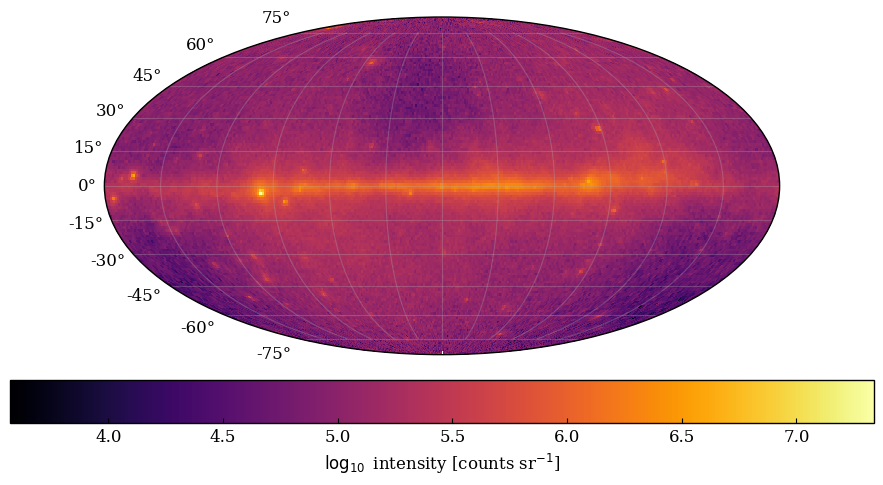

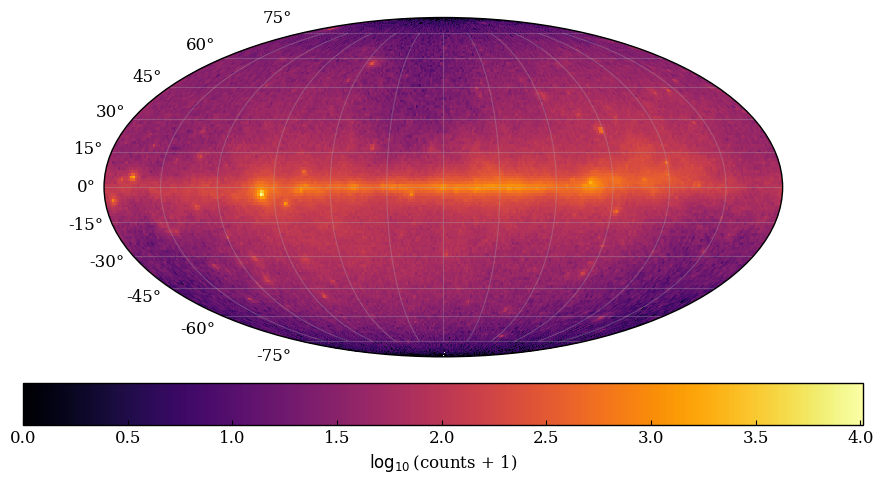

In [ ]:
def plot_skymap(l_edges, b_edges, values, out_path, label="log10(intensity)"):
    l_centers = 0.5 * (l_edges[:-1] + l_edges[1:])
    b_centers = 0.5 * (b_edges[:-1] + b_edges[1:])
    L, B = np.meshgrid(np.radians(l_centers), np.radians(b_centers))

    fig = plt.figure(figsize=(9, 5))
    ax = fig.add_subplot(111, projection="mollweide")
    mesh = ax.pcolormesh(L, B, np.log10(values.T),
                          shading="auto", cmap="inferno")
    ax.set_xticklabels([])  # longitude tick labels are not very readable in Mollweide
    ax.grid(True, alpha=0.3)
    fig.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.06, label=label)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300)

plot_skymap(l_edges, b_edges, intensity, "figures/skymap_intensity.png",
            label=r"$\log_{10}$ intensity [counts sr$^{-1}$]")
plot_skymap(l_edges, b_edges, counts, "figures/skymap_counts.png",
            label=r"$\log_{10}$(counts + 1)")

/tmp/ipykernel_725/301719599.py:8: RuntimeWarning: divide by zero encountered in log10
  mesh = ax.pcolormesh(L, B, np.log10(values.T),


E > 0.01 GeV: 2395038 events


/tmp/ipykernel_725/301719599.py:8: RuntimeWarning: divide by zero encountered in log10
  mesh = ax.pcolormesh(L, B, np.log10(values.T),


E > 0.1 GeV: 1592037 events


/tmp/ipykernel_725/301719599.py:8: RuntimeWarning: divide by zero encountered in log10
  mesh = ax.pcolormesh(L, B, np.log10(values.T),


E > 1 GeV: 220706 events


/tmp/ipykernel_725/301719599.py:8: RuntimeWarning: divide by zero encountered in log10
  mesh = ax.pcolormesh(L, B, np.log10(values.T),


E > 10 GeV: 7269 events


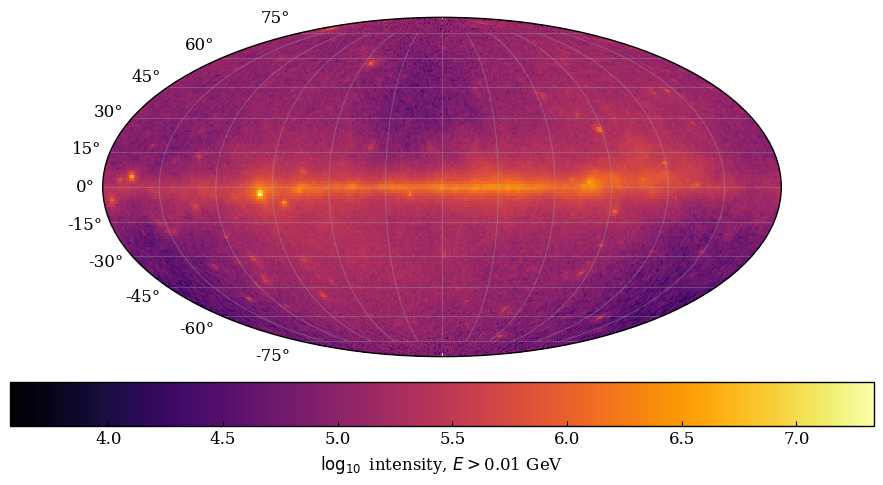

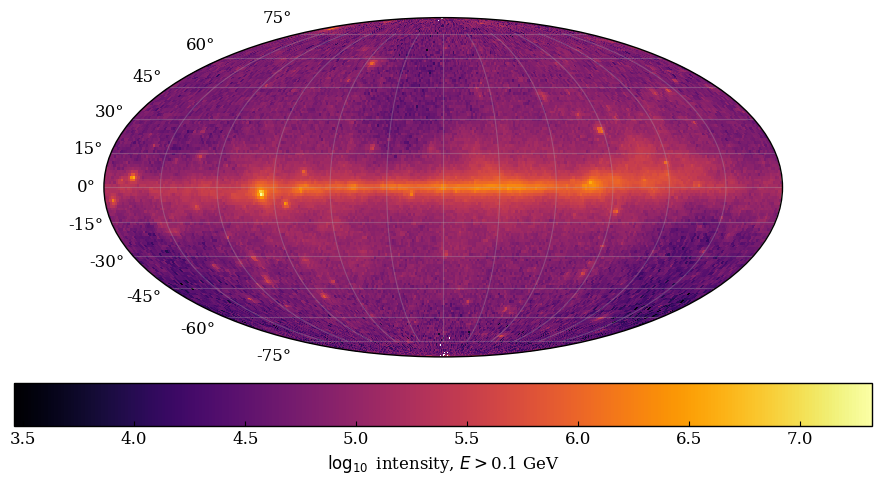

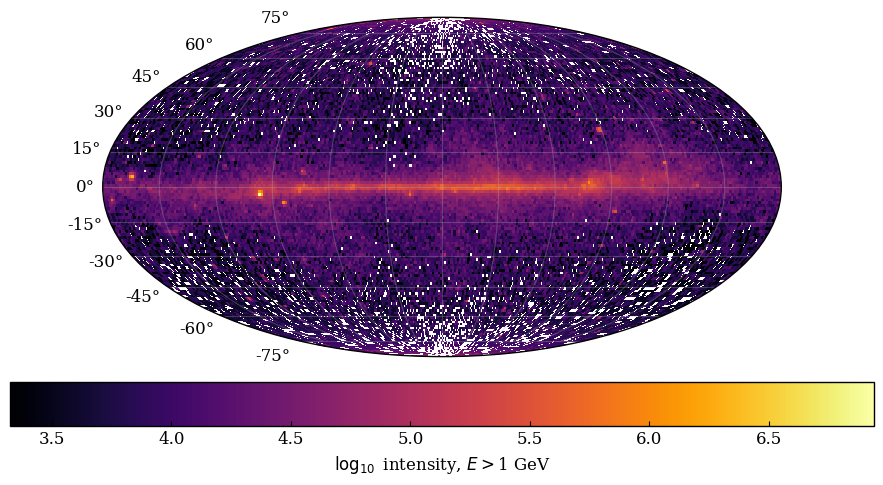

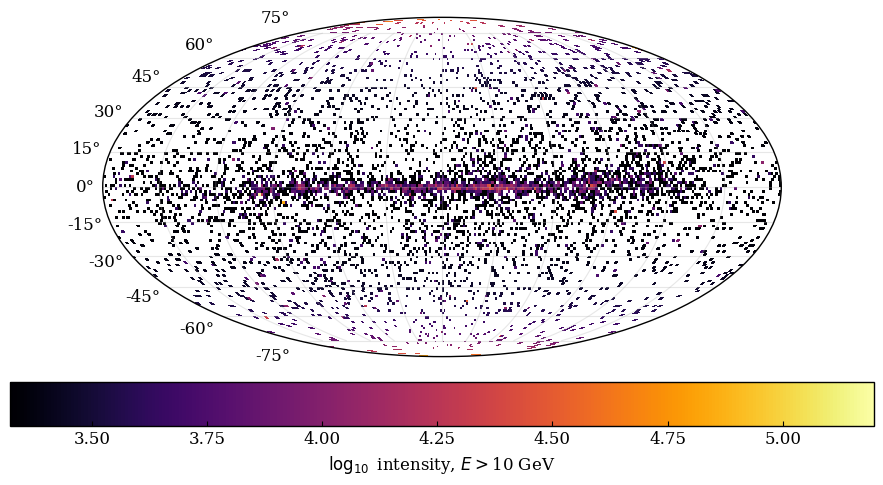

In [ ]:
for e_min_gev, tag in [(0.01, "10MeV"), (0.1, "100MeV"), (1.0, "1GeV"), (10.0, "10GeV")]:
    sel_e = sel_events[sel_events["ENERGY"] > e_min_gev * 1000.0]
    l_e, b_e, counts_e, intensity_e = bin_skymap(sel_e)
    plot_skymap(l_e, b_e, intensity_e, f"figures/skymap_{tag}.png",
                label=fr"$\log_{{10}}$ intensity, $E>${e_min_gev:g} GeV")
    print(f"E > {e_min_gev:g} GeV: {len(sel_e)} events")

In [69]:
from astropy.time import Time

FERMI_MET_REF = Time("2001-01-01T00:00:00", scale="utc")

def met_to_date(met_seconds):
    """Convert Fermi Mission Elapsed Time (seconds) to a calendar date."""
    return FERMI_MET_REF + met_seconds * (1 / 86400)  # add days

gal_events, gal_gti = load_fermi_events("data/galactic_plane_photons.fits")

t_start = met_to_date(gal_gti["START"].min())
t_stop = met_to_date(gal_gti["STOP"].max())
print(f"Loaded {len(gal_events)} events")
print(f"Energy range: [{gal_events['ENERGY'].min():.1f}, "
      f"{gal_events['ENERGY'].max():.1f}] MeV")
print(f"Observation period: {t_start.iso} to {t_stop.iso}")

Loaded 3762060 events
Energy range: [300.0, 298929.5] MeV
Observation period: 2026-01-23 11:05:23.000 to 2026-05-07 00:56:47.085


In [70]:
E_MIN_MEV = 1000.0  # 1 GeV
high_E = gal_events[gal_events["ENERGY"] > E_MIN_MEV]
print(f"{len(high_E)} / {len(gal_events)} events pass E > {E_MIN_MEV:.0f} MeV")

959958 / 3762060 events pass E > 1000 MeV


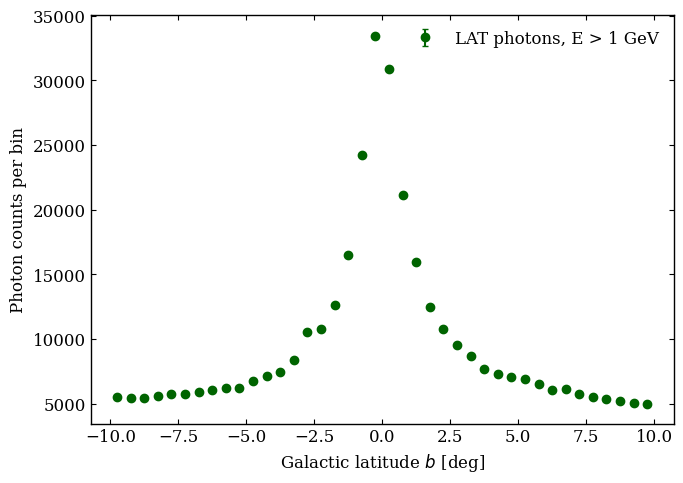

In [71]:
b_bins = np.linspace(-10, 10, 41)  # 0.5 deg bins, |b| < 10 deg
counts, edges = np.histogram(high_E["B"], bins=b_bins)
b_centers = 0.5 * (edges[:-1] + edges[1:])
counts_err = np.sqrt(np.maximum(counts, 1))  # Poisson errors

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(b_centers, counts, yerr=counts_err, fmt="o", color="darkgreen",
            capsize=2, label="LAT photons, E > 1 GeV")
ax.set_xlabel("Galactic latitude $b$ [deg]")
ax.set_ylabel("Photon counts per bin")
ax.legend(); fig.tight_layout()
fig.savefig("figures/latitude_profile.png", dpi=300)

Fitted scale height: b0 = 5.19 +/- 0.02 deg


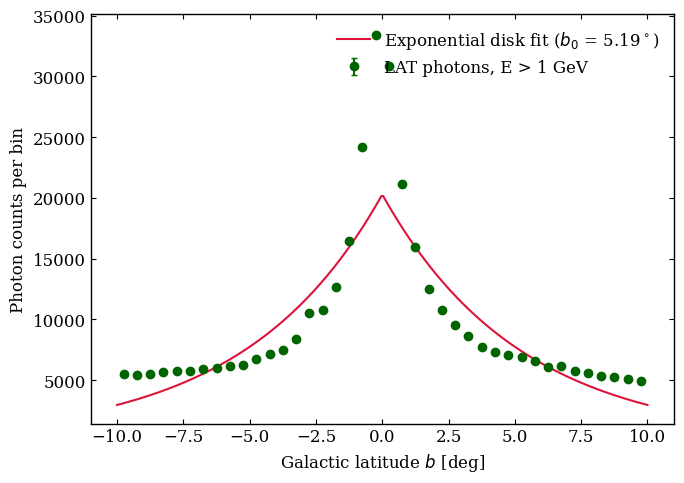

In [72]:
from scipy.optimize import curve_fit

def exponential_disk(b, I0, b0):
    return I0 * np.exp(-np.abs(b) / b0)

popt, pcov = curve_fit(exponential_disk, b_centers, counts,
                        sigma=counts_err, p0=[counts.max(), 3.0],
                        absolute_sigma=True)
I0_fit, b0_fit = popt
b0_err = np.sqrt(pcov[1, 1])
print(f"Fitted scale height: b0 = {b0_fit:.2f} +/- {b0_err:.2f} deg")

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(b_centers, counts, yerr=counts_err, fmt="o", color="darkgreen",
            capsize=2, label="LAT photons, E > 1 GeV")
b_fine = np.linspace(-10, 10, 300)
ax.plot(b_fine, exponential_disk(b_fine, *popt), "-", color="crimson",
        label=fr"Exponential disk fit ($b_0$ = {b0_fit:.2f}$^\circ$)")
ax.set_xlabel("Galactic latitude $b$ [deg]")
ax.set_ylabel("Photon counts per bin")
ax.legend(); fig.tight_layout()
fig.savefig("figures/latitude_profile_fit.png", dpi=300)

In [59]:
VELA_RA_DEG, VELA_DEC_DEG = 128.836, -45.176

def angular_separation_deg(ra1, dec1, ra2, dec2):
    ra1, dec1, ra2, dec2 = map(np.radians, (ra1, dec1, ra2, dec2))
    cos_sep = (np.sin(dec1) * np.sin(dec2)
               + np.cos(dec1) * np.cos(dec2) * np.cos(ra1 - ra2))
    cos_sep = np.clip(cos_sep, -1.0, 1.0)  # guard against roundoff
    return np.degrees(np.arccos(cos_sep))

vela_events, vela_gti = load_fermi_events("data/vela_photons.fits")
sep = angular_separation_deg(vela_events["RA"], vela_events["DEC"],
                              VELA_RA_DEG, VELA_DEC_DEG)
roi_events = vela_events[sep <= 1.0]
print(f"{len(roi_events)} / {len(vela_events)} events within 1 deg of Vela")

47462 / 768493 events within 5 deg of Vela


In [60]:
E_bins = np.logspace(np.log10(100), np.log10(1e5), 21)  # MeV
E_counts, E_edges = np.histogram(roi_events["ENERGY"], bins=E_bins)
E_centers = np.sqrt(E_edges[:-1] * E_edges[1:])  # geometric bin center
E_counts_err = np.sqrt(np.maximum(E_counts, 1))

good = E_counts > 0
print(f"{len(E_bins) - 1} energy bins spanning "
      f"{E_edges[0]:.0f}-{E_edges[-1]:.0f} MeV; "
      f"{good.sum()} bins contain at least one photon")

20 energy bins spanning 100-100000 MeV; 19 bins contain at least one photon


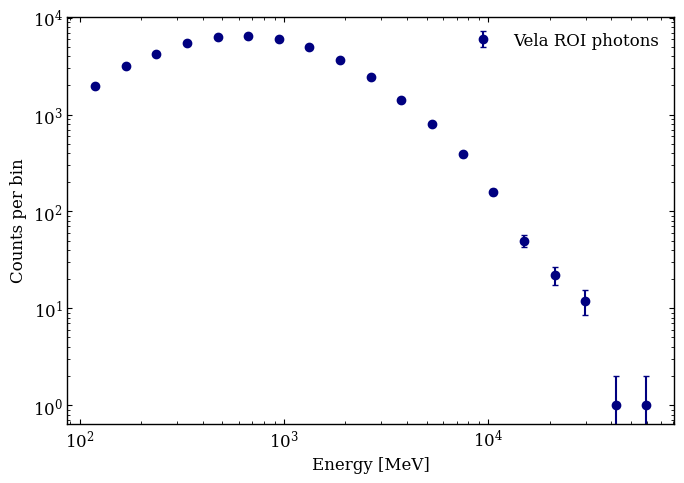

In [61]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(E_centers[good], E_counts[good], yerr=E_counts_err[good],
            fmt="o", color="navy", capsize=2, label="Vela ROI photons")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Energy [MeV]"); ax.set_ylabel("Counts per bin")
ax.legend(); fig.tight_layout()
fig.savefig("figures/vela_spectrum_counts.png", dpi=300)

Power-law photon index: Gamma = 1.45 +/- 0.02


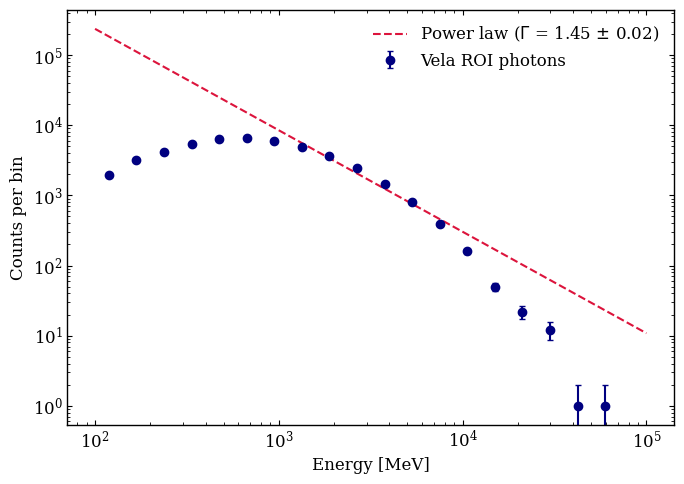

In [63]:
def power_law(E, A, Gamma):
    return A * E**(-Gamma)

def log_power_law(logE, logA, Gamma):
    return logA - Gamma * logE

mask = (E_centers > 1000) & (E_counts > 0)

popt_pl, pcov_pl = curve_fit(
    log_power_law, np.log10(E_centers[mask]), np.log10(E_counts[mask]),
    sigma=E_counts_err[mask] / (E_counts[mask] * np.log(10)),
    p0=[np.log10(E_counts[mask][0]), 1.6], absolute_sigma=True
)
Gamma_fit = popt_pl[1]
Gamma_err = np.sqrt(pcov_pl[1, 1])
print(f"Power-law photon index: Gamma = {Gamma_fit:.2f} +/- {Gamma_err:.2f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(E_centers[good], E_counts[good], yerr=E_counts_err[good],
            fmt="o", color="navy", capsize=2, label="Vela ROI photons")
E_fine = np.logspace(np.log10(100), np.log10(1e5), 200)
ax.plot(E_fine, power_law(E_fine, 10**popt_pl[0], Gamma_fit), "--", color="crimson",
        label=fr"Power law ($Γ$ = {Gamma_fit:.2f} $\pm$ {Gamma_err:.2f})")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Energy [MeV]"); ax.set_ylabel("Counts per bin")
ax.legend(); fig.tight_layout()
fig.savefig("figures/vela_spectrum_powerlaw.png", dpi=300)

Cutoff power-law fit: Gamma = 0.68, E_c = 4551 +/- 264 MeV


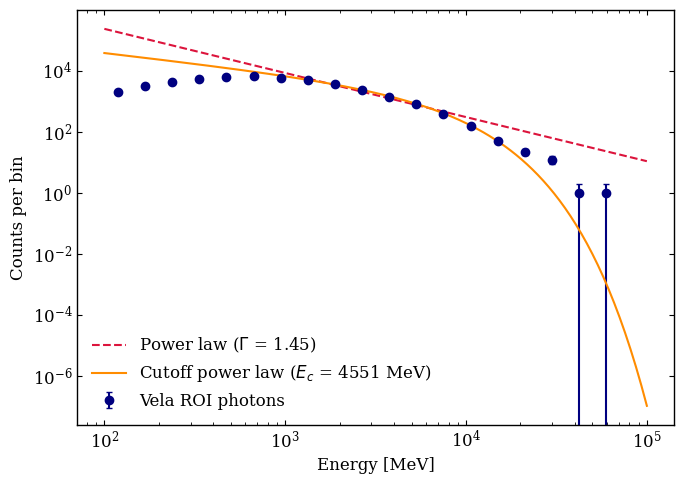

In [74]:
def cutoff_power_law(E, A, Gamma, Ec):
    return A * E**(-Gamma) * np.exp(-E / Ec)

popt_cpl, pcov_cpl = curve_fit(
    cutoff_power_law, E_centers[mask], E_counts[mask],
    sigma=E_counts_err[mask], p0=[E_counts[mask][0] * 100, 1.5, 3000.0],
    absolute_sigma=True, maxfev=10000
)
Ec_fit = popt_cpl[2]
Ec_err = np.sqrt(pcov_cpl[2, 2])
print(f"Cutoff power-law fit: Gamma = {popt_cpl[1]:.2f}, "
      f"E_c = {Ec_fit:.0f} +/- {Ec_err:.0f} MeV")

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(E_centers[good], E_counts[good], yerr=E_counts_err[good],
            fmt="o", color="navy", capsize=2, label="Vela ROI photons")
E_fine = np.logspace(np.log10(100), np.log10(1e5), 200)
ax.plot(E_fine, power_law(E_fine, 10**popt_pl[0], Gamma_fit), "--", color="crimson",
        label=fr"Power law ($\Gamma$ = {Gamma_fit:.2f})")
ax.plot(E_fine, cutoff_power_law(E_fine, *popt_cpl), "-", color="darkorange",
        label=fr"Cutoff power law ($E_c$ = {Ec_fit:.0f} MeV)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Energy [MeV]"); ax.set_ylabel("Counts per bin")
ax.legend(); fig.tight_layout()
fig.savefig("figures/vela_spectrum_cutoff.png", dpi=300)